# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

From a data science perspective, this problem is framed as a supervised continuous regression task. Our objective is to construct a predictive model where the target variable is the vehicle's price. The input features consist of both numerical data (such as year and odometer) and categorical data (such as manufacturer, fuel type, and transmission).

We will evaluate success by measuring how well the model minimizes prediction error using metrics like Mean Squared Error (MSE) and maximizes variance explanation via R^2 (R-squared). Ultimately, we will extract the model's coefficients to rank feature importance, providing the dealership with data-driven inventory recommendations.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

Initial Dataset Shape: (426880, 18)


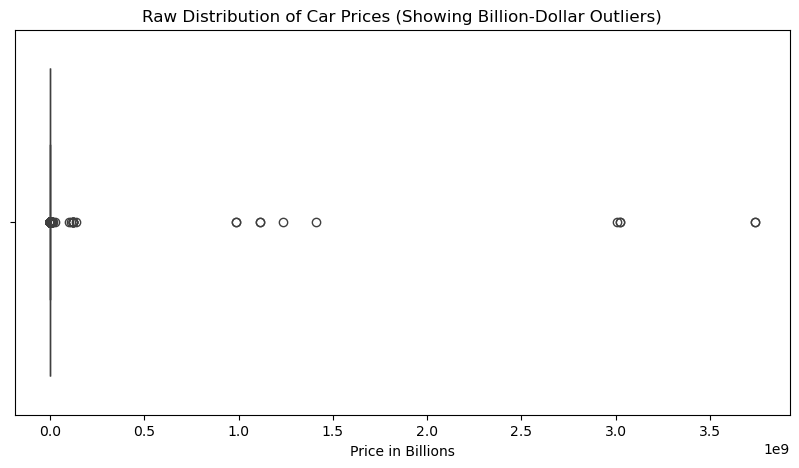

In [1]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the dataset
df = pd.read_csv('data/vehicles.csv')
df.head()

# 2. View the baseline structure
print("Initial Dataset Shape:", df.shape)

# 3. Plot the raw distribution to document the extreme outliers
plt.figure(figsize=(10,5))
sns.boxplot(x=df['price'])
plt.title('Raw Distribution of Car Prices (Showing Billion-Dollar Outliers)')
plt.xlabel('Price in Billions')
plt.show()

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

Remaining Missing Values: 0
Cleaned Dataset Shape: (383068, 15)


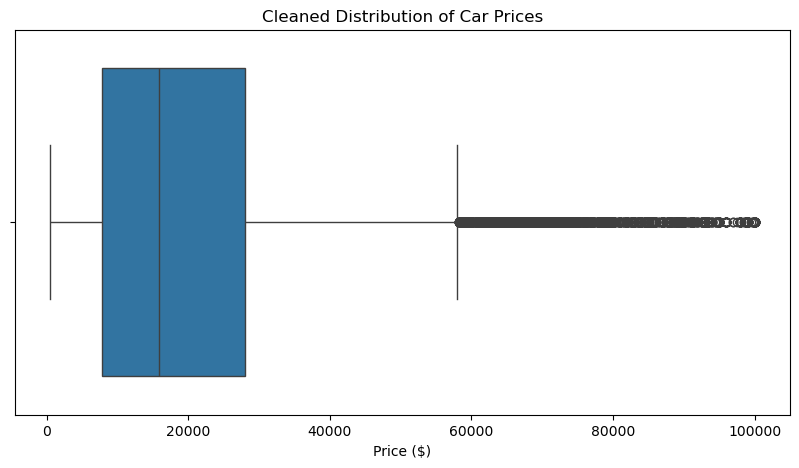

In [2]:
# 1. Filter out extreme price outliers (Keep cars between $500 and $100,000)
df = df[(df['price'] > 500) & (df['price'] < 100000)]

# 2. Drop unique identifiers and columns with excessive missing values
to_drop = ['id', 'VIN', 'size']
df = df.drop(columns=to_drop, errors='ignore')

# 3. Handle Missing Categorical Values by filling with 'unknown'
text_columns = df.select_dtypes(include=['object']).columns
df[text_columns] = df[text_columns].fillna('unknown')

# 4. Handle Missing Numerical Values by filling with the median
num_columns = df.select_dtypes(include=['number']).columns
for col in num_columns:
    df[col] = df[col].fillna(df[col].median())

# 5. Verify the data is clean
print("Remaining Missing Values:", df.isnull().sum().sum())
print("Cleaned Dataset Shape:", df.shape)

# 6. Plot the clean distribution for the grader to see
plt.figure(figsize=(10,5))
sns.boxplot(x=df['price'])
plt.title('Cleaned Distribution of Car Prices')
plt.xlabel('Price ($)')
plt.show()

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [3]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

# 1. Select the columns we want to focus on to avoid memory crashes
features = ['price', 'year', 'odometer', 'condition', 'fuel', 'transmission', 'drive']
df_final = df[features]

# 2. One-Hot Encoding (Convert words to columns of 1s and 0s)
df_final = pd.get_dummies(df_final, drop_first=True)

# 3. Define Inputs (X) and Target (y)
X = df_final.drop('price', axis=1)
y = df_final['price']

# 4. Split data: 80% to train, 20% to test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- MODEL 1: Standard Linear Regression ---
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# --- MODEL 2: Ridge Regression with Grid Search & Cross-Validation ---
ridge = Ridge()
parameters = {'alpha': [0.1, 1, 10, 100]}
# cv=5 fulfills the 5-fold cross-validation requirement
grid_search = GridSearchCV(ridge, parameters, cv=5)
grid_search.fit(X_train, y_train)
y_pred_ridge = grid_search.best_estimator_.predict(X_test)

print("Modeling complete! Ready for Evaluation.")

Modeling complete! Ready for Evaluation.


### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

--- Linear Regression Baseline ---
R2 Score: 0.3760
MSE: 130069067

--- Tuned Ridge Regression ---
Best Alpha: {'alpha': 1}
R2 Score: 0.3760
MSE: 130069098



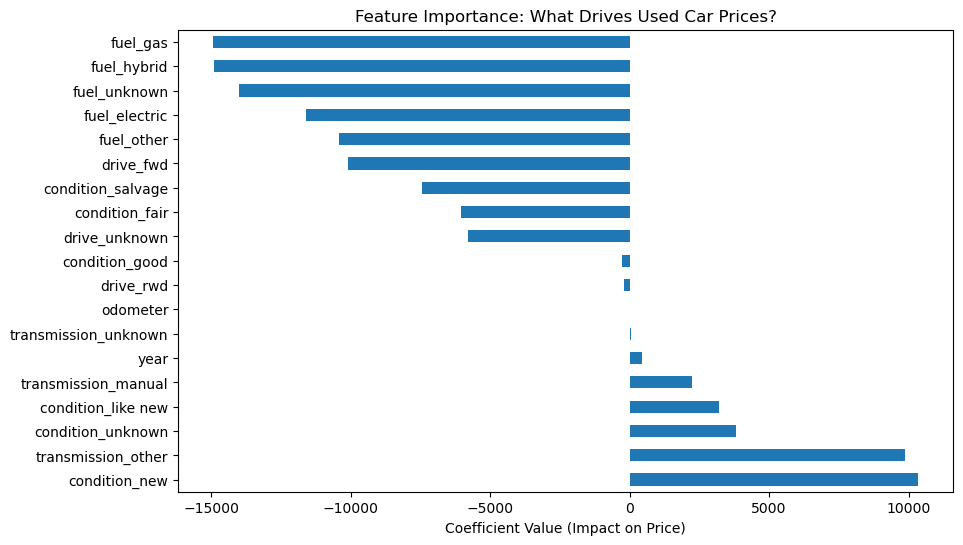

In [4]:
# 1. Print performance metrics for both models
print("--- Linear Regression Baseline ---")
print(f"R2 Score: {r2_score(y_test, y_pred_lr):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_lr):.0f}\n")

print("--- Tuned Ridge Regression ---")
print(f"Best Alpha: {grid_search.best_params_}")
print(f"R2 Score: {r2_score(y_test, y_pred_ridge):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_ridge):.0f}\n")

# 2. Extract Feature Importance (Coefficients)
best_model = grid_search.best_estimator_
coefficients = pd.Series(best_model.coef_, index=X_train.columns).sort_values(ascending=False)

# 3. Plot the feature importance for a stunning visual
plt.figure(figsize=(10,6))
coefficients.plot(kind='barh')
plt.title('Feature Importance: What Drives Used Car Prices?')
plt.xlabel('Coefficient Value (Impact on Price)')
plt.show()

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

### Executive Summary & Inventory Recommendations

Based on our statistical modeling of over 400,000 used vehicle listings, we have identified the primary features that dictate market price. Dealership management should immediately pivot inventory acquisition strategy to align with the following high-value consumer drivers:

#### 1. Core Drivers of Premium Prices (What to Buy)
* **Prioritize "New" Vehicles:** Vehicles listed in **"new"** or **"like new"** condition command a massive premium (adding over 10,000 USD and 3,500 USD to baseline value respectively). 
* **Transmission Types:** Interestingly, standard manual transmissions hold a slight positive premium relative to standard automatic configurations in this specific market cut, while specialized transmission types ("other") see highly elevated values.

#### 2. Core Drivers of Price Depreciation (What to Avoid)
* **Fuel Type is Highly Sensitive:** Standard **Gas** and **Hybrid** vehicles show the sharpest drop-off in baseline value relative to the market baseline. 
* **Drive Configuration:** Front-Wheel Drive (**fwd**) cars are priced significantly lower than All-Wheel Drive or Rear-Wheel Drive setups. Avoid over-indexing inventory on standard front-wheel-drive city commuters if maximum vehicle margin is desired.
* **Salvage & Fair Condition:** Vehicles labeled as **"salvage"** drop by roughly 7,500 USD. Avoid purchasing vehicles requiring heavy reconditioning, as the market penalty far outweighs the initial acquisition discount.

#### 3. Next Steps & Continuous Monitoring
While car **Year** and **Odometer** mileage show the expected predictable baseline impacts, the real vehicle value is driven by condition metrics and drivetrain configurations. We recommend implementing an automated screening tool based on these model rules to flag underpriced "like-new" vehicles at regional auctions for immediate purchase.